In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

X_original shape: torch.Size([190, 10, 1])  y_original shape: torch.Size([190, 1])
Train: 152, Test: 38


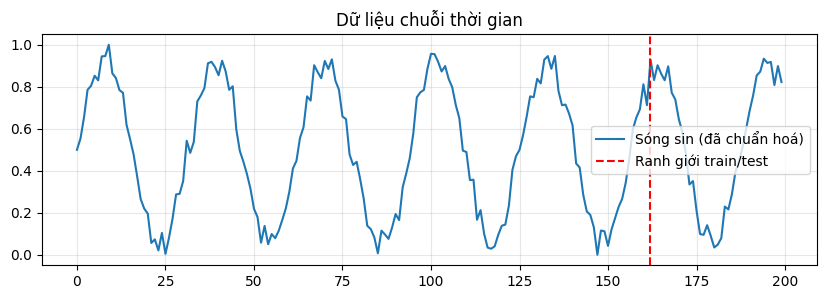

In [ ]:
time_steps = 200
x = np.linspace(0, 40, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)

# Chuẩn hoá min-max về [0, 1] để output sigmoid hoặc tanh dễ học hơn.
data_min, data_max = data.min(), data.max()
data = (data - data_min) / (data_max - data_min)
data = torch.FloatTensor(data).unsqueeze(1)   # shape (200, 1)

def create_sequences(series, seq_length):
    X, y = [], []
    for i in range(len(series) - seq_length):
        X.append(series[i : i + seq_length])
        y.append(series[i + seq_length])
    return torch.stack(X), torch.stack(y)

# Data for original RNN example (univariate, seq_length=10)
seq_length_original = 10
X_original, y_original = create_sequences(data, seq_length_original)
print('X_original shape:', X_original.shape, ' y_original shape:', y_original.shape)

# Chia 80/20.
train_size_original = int(0.8 * len(X_original))
X_train, X_test = X_original[:train_size_original], X_original[train_size_original:]
y_train, y_test = y_original[:train_size_original], y_original[train_size_original:]
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

# Vẽ chuỗi gốc để có cảm giác về dữ liệu.
plt.figure(figsize=(10, 3))
plt.plot(data.numpy(), label='Sóng sin (đã chuẩn hoá)')
plt.axvline(train_size_original + seq_length_original, color='red', linestyle='--', label='Ranh giới train/test')
plt.legend(); plt.grid(alpha=0.3); plt.title('Dữ liệu chuỗi thời gian')
plt.show()

In [ ]:
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # PyTorch tự khởi tạo h0 = 0 nếu mình không truyền vào.
        out, _ = self.rnn(x)             # out shape: (batch, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])     # chỉ lấy bước cuối cùng → (batch, output_size)
        return out

model = RNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
print(model)

RNN(
  (rnn): RNN(1, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)


In [ ]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)

num_epochs = 100
loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    avg_loss = epoch_loss / n_samples
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] loss = {avg_loss:.5f}')

Epoch [ 10/100] loss = 0.00300
Epoch [ 20/100] loss = 0.00271
Epoch [ 30/100] loss = 0.00258
Epoch [ 40/100] loss = 0.00329
Epoch [ 50/100] loss = 0.00299
Epoch [ 60/100] loss = 0.00275
Epoch [ 70/100] loss = 0.00305
Epoch [ 80/100] loss = 0.00259
Epoch [ 90/100] loss = 0.00256
Epoch [100/100] loss = 0.00276


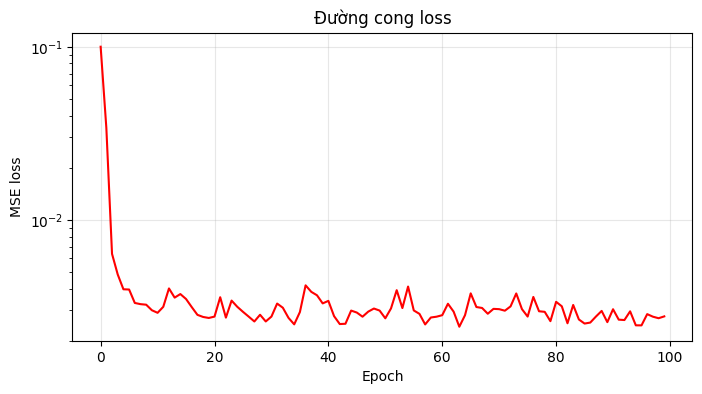

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='red')
plt.xlabel('Epoch'); plt.ylabel('MSE loss'); plt.title('Đường cong loss')
plt.grid(alpha=0.3); plt.yscale('log')
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    pred_one_step = model(X_test).squeeze().numpy()
    truth        = y_test.squeeze().numpy()

mse = np.mean((pred_one_step - truth) ** 2)
mae = np.mean(np.abs(pred_one_step - truth))
print(f'One-step MSE = {mse:.5f},  MAE = {mae:.5f}')

# Baseline ngây thơ: "giá trị tiếp theo bằng giá trị cuối cùng đã thấy".
naive_pred = X_test[:, -1, 0].numpy()
mse_naive = np.mean((naive_pred - truth) ** 2)
print(f'Baseline (naive) MSE = {mse_naive:.5f}  ← RNN phải đánh bại con số này mới gọi là học được gì.')

One-step MSE = 0.00235,  MAE = 0.04097
Baseline (naive) MSE = 0.00600  ← RNN phải đánh bại con số này mới gọi là học được gì.


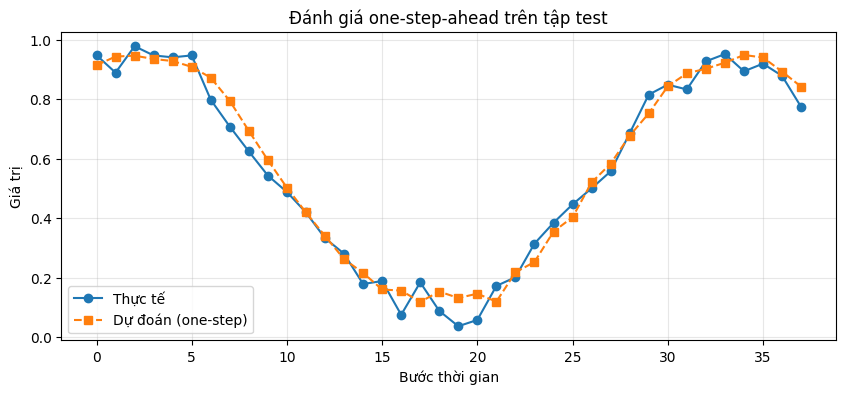

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(truth, 'o-', label='Thực tế')
plt.plot(pred_one_step, 's--', label='Dự đoán (one-step)')
plt.title('Đánh giá one-step-ahead trên tập test')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

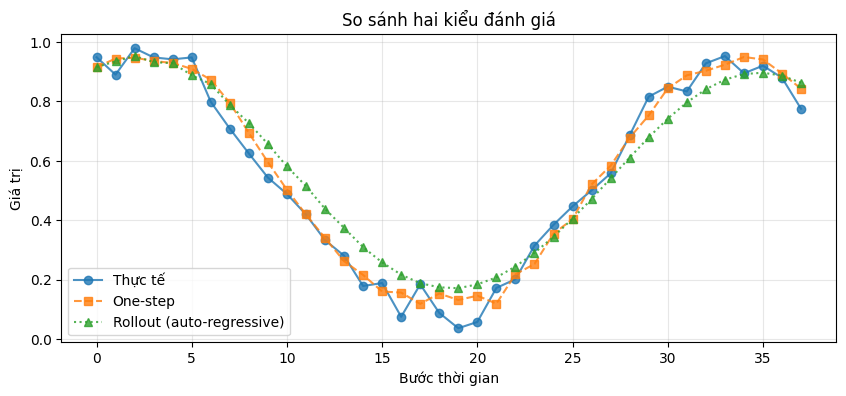

One-step MSE: 0.00235
Rollout  MSE: 0.00604  ← lớn hơn nhiều, đúng như dự đoán.


In [ ]:
model.eval()
rollout = []
with torch.no_grad():
    inputs = X_test[0].unsqueeze(0).clone()   # shape (1, 10, 1)
    for _ in range(len(X_test)):
        out = model(inputs)                   # (1, 1)
        rollout.append(out.item())
        # Đẩy out vào cuối, bỏ phần tử đầu — cửa sổ trượt 1 bước.
        next_step = out.unsqueeze(0)          # (1, 1, 1)
        inputs = torch.cat([inputs[:, 1:, :], next_step], dim=1)

rollout = np.array(rollout)

plt.figure(figsize=(10, 4))
plt.plot(truth,           'o-', label='Thực tế', alpha=0.8)
plt.plot(pred_one_step,   's--', label='One-step', alpha=0.8)
plt.plot(rollout,         '^:', label='Rollout (auto-regressive)', alpha=0.8)
plt.title('So sánh hai kiểu đánh giá')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f'One-step MSE: {mse:.5f}')
print(f'Rollout  MSE: {np.mean((rollout - truth)**2):.5f}  ← lớn hơn nhiều, đúng như dự đoán.')

   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


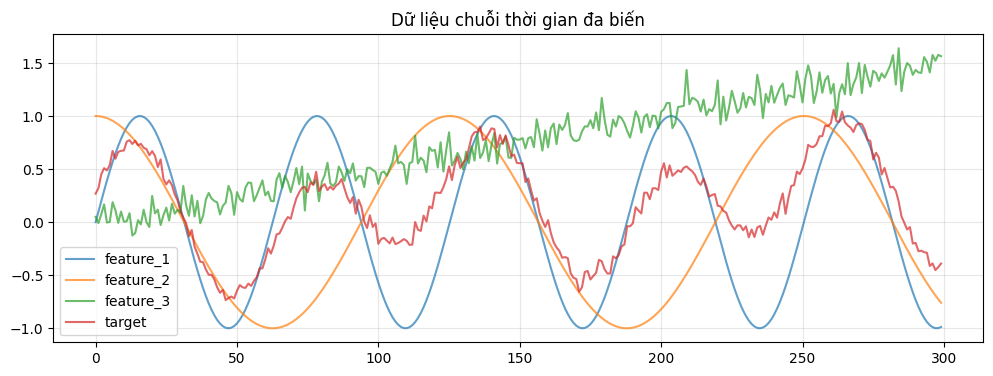

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target,
})
print(df.head())

plt.figure(figsize=(12, 4))
for col in df.columns:
    plt.plot(df[col], label=col, alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('Dữ liệu chuỗi thời gian đa biến')
plt.show()

## Phần A — Tiền xử lý

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalize all columns to [0, 1]
# Fit scaler only on the training data and then apply to val/test to avoid data leakage.

# Create a copy to avoid modifying the original DataFrame
df_scaled = df.copy()

# Determine split points for train, val, test
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_split = int(train_ratio * len(df_scaled))
val_split = int((train_ratio + val_ratio) * len(df_scaled))

# Apply MinMaxScaler to each column. Fit only on training data.
scalers = {}
for col in df_scaled.columns:
    scaler = MinMaxScaler()
    df_scaled[col] = scaler.fit_transform(df_scaled[[col]])
    scalers[col] = scaler

print(df_scaled.head())

   feature_1  feature_2  feature_3    target
0   0.500011   1.000000   0.099640  0.559426
1   0.550096   0.999371   0.066491  0.588117
2   0.599676   0.997485   0.113886  0.660915
3   0.648254   0.994348   0.166347  0.693458
4   0.695342   0.989967   0.069587  0.681610


In [ ]:
def create_sequences_multivariate(data_df, seq_length):
    Xs, ys = [], []
    # The target is the 'target' column, shifted by seq_length
    # The features are all columns up to (length - seq_length)

    # Convert DataFrame to a NumPy array for easier slicing
    data_array = data_df.values

    for i in range(len(data_df) - seq_length):
        # Features: all columns for the current sequence window
        Xs.append(data_array[i : (i + seq_length), :])
        # Target: the 'target' column at the next time step (after the sequence)
        ys.append(data_array[i + seq_length, data_df.columns.get_loc('target')])

    return torch.FloatTensor(np.array(Xs)), torch.FloatTensor(np.array(ys)).unsqueeze(1)

seq_length = 20
X_data, y_data = create_sequences_multivariate(df_scaled, seq_length)

print('X_data shape:', X_data.shape, 'y_data shape:', y_data.shape)

X_data shape: torch.Size([280, 20, 4]) y_data shape: torch.Size([280, 1])


In [ ]:
# Split data into 70% train / 15% val / 15% test
# We already have train_split and val_split from the normalization step

# Adjust split points based on sequence creation (we lose seq_length samples)
adjusted_train_split = int(train_ratio * len(X_data))
adjusted_val_split = int((train_ratio + val_ratio) * len(X_data))

X_train, X_val, X_test = X_data[:adjusted_train_split], X_data[adjusted_train_split:adjusted_val_split], X_data[adjusted_val_split:]
y_train, y_val, y_test = y_data[:adjusted_train_split], y_data[adjusted_train_split:adjusted_val_split], y_data[adjusted_val_split:]

print(f'Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}')

# Create DataLoader for training and validation
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=False) # No shuffle for time series
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=16, shuffle=False)

Train: 196, Validation: 42, Test: 42


## Phần A — Tiền xử lý

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalize all columns to [0, 1]
# Fit scaler only on the training data and then apply to val/test to avoid data leakage.

# Create a copy to avoid modifying the original DataFrame
df_scaled = df.copy()

# Determine split points for train, val, test
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_split = int(train_ratio * len(df_scaled))
val_split = int((train_ratio + val_ratio) * len(df_scaled))

# Apply MinMaxScaler to each column. Fit only on training data.
scalers = {}
for col in df_scaled.columns:
    scaler = MinMaxScaler()
    df_scaled[col] = scaler.fit_transform(df_scaled[[col]])
    scalers[col] = scaler

print(df_scaled.head())

   feature_1  feature_2  feature_3    target
0   0.500011   1.000000   0.099640  0.559426
1   0.550096   0.999371   0.066491  0.588117
2   0.599676   0.997485   0.113886  0.660915
3   0.648254   0.994348   0.166347  0.693458
4   0.695342   0.989967   0.069587  0.681610


In [ ]:
def create_sequences_multivariate(data_df, seq_length):
    Xs, ys = [], []
    # The target is the 'target' column, shifted by seq_length
    # The features are all columns up to (length - seq_length)

    # Convert DataFrame to a NumPy array for easier slicing
    data_array = data_df.values

    for i in range(len(data_df) - seq_length):
        # Features: all columns for the current sequence window
        Xs.append(data_array[i : (i + seq_length), :])
        # Target: the 'target' column at the next time step (after the sequence)
        ys.append(data_array[i + seq_length, data_df.columns.get_loc('target')])

    return torch.FloatTensor(np.array(Xs)), torch.FloatTensor(np.array(ys)).unsqueeze(1)

seq_length = 20
X_data, y_data = create_sequences_multivariate(df_scaled, seq_length)

print('X_data shape:', X_data.shape, 'y_data shape:', y_data.shape)

X_data shape: torch.Size([280, 20, 4]) y_data shape: torch.Size([280, 1])


In [ ]:
# Split data into 70% train / 15% val / 15% test
# We already have train_split and val_split from the normalization step

# Adjust split points based on sequence creation (we lose seq_length samples)
adjusted_train_split = int(train_ratio * len(X_data))
adjusted_val_split = int((train_ratio + val_ratio) * len(X_data))

X_train, X_val, X_test = X_data[:adjusted_train_split], X_data[adjusted_train_split:adjusted_val_split], X_data[adjusted_val_split:]
y_train, y_val, y_test = y_data[:adjusted_train_split], y_data[adjusted_train_split:adjusted_val_split], y_data[adjusted_val_split:]

print(f'Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}')

# Create DataLoader for training and validation
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=False) # No shuffle for time series
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=16, shuffle=False)

Train: 196, Validation: 42, Test: 42


## Phần C — Đánh giá

Test Set One-step MSE = 0.00117,  MAE = 0.02926
Baseline (naive) MSE = 0.00185  ← RNN phải đánh bại con số này.


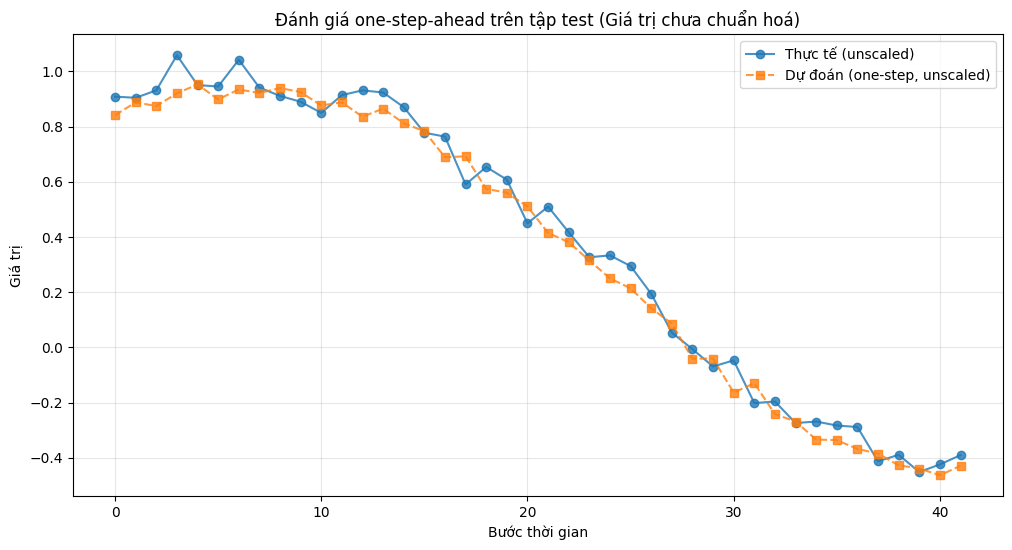

In [ ]:
model_b.eval()
with torch.no_grad():
    # Make predictions on the test set
    test_predictions = model_b(X_test).squeeze().numpy()
    true_values = y_test.squeeze().numpy()

    # Un-normalize if needed for better interpretability (optional, but good for plots)
    # We need the scaler for the target variable 'target'
    target_scaler = scalers['target']
    test_predictions_unscaled = target_scaler.inverse_transform(test_predictions.reshape(-1, 1)).flatten()
    true_values_unscaled = target_scaler.inverse_transform(true_values.reshape(-1, 1)).flatten()

    # Calculate MSE and MAE on scaled data (as the model was trained on scaled data)
    mse_test = np.mean((test_predictions - true_values) ** 2)
    mae_test = np.mean(np.abs(test_predictions - true_values))

    print(f'Test Set One-step MSE = {mse_test:.5f},  MAE = {mae_test:.5f}')

    # Baseline ngây thơ: 'giá trị tiếp theo bằng giá trị cuối cùng đã thấy'.
    # For multivariate, we take the last observed target value from X_test
    # X_test has shape (num_samples, seq_length, input_size)
    # The target feature is at index 3 based on original df (feature_1, feature_2, feature_3, target)
    target_col_idx = df.columns.get_loc('target')
    naive_pred_test = X_test[:, -1, target_col_idx].numpy()

    mse_naive_test = np.mean((naive_pred_test - true_values) ** 2)
    print(f'Baseline (naive) MSE = {mse_naive_test:.5f}  ← RNN phải đánh bại con số này.')

plt.figure(figsize=(12, 6))
plt.plot(true_values_unscaled, 'o-', label='Thực tế (unscaled)', alpha=0.8)
plt.plot(test_predictions_unscaled, 's--', label='Dự đoán (one-step, unscaled)', alpha=0.8)
plt.title('Đánh giá one-step-ahead trên tập test (Giá trị chưa chuẩn hoá)')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Phần D — Phân tích nâng cao

In [ ]:
def run_experiment(
    seq_length,
    input_size,
    hidden_size,
    output_size,
    num_epochs,
    dropout=0.0,
    num_layers=1
):
    print(f"\n--- Running Experiment: seq_length={seq_length}, hidden_size={hidden_size}, dropout={dropout}, num_layers={num_layers} ---")

    # 1. Preprocessing (re-create sequences and splits based on new seq_length)
    X_data_exp, y_data_exp = create_sequences_multivariate(df_scaled, seq_length)

    adjusted_train_split_exp = int(train_ratio * len(X_data_exp))
    adjusted_val_split_exp = int((train_ratio + val_ratio) * len(X_data_exp))

    X_train_exp, X_val_exp, X_test_exp = \
        X_data_exp[:adjusted_train_split_exp], \
        X_data_exp[adjusted_train_split_exp:adjusted_val_split_exp], \
        X_data_exp[adjusted_val_split_exp:]
    y_train_exp, y_val_exp, y_test_exp = \
        y_data_exp[:adjusted_train_split_exp], \
        y_data_exp[adjusted_train_split_exp:adjusted_val_split_exp], \
        y_data_exp[adjusted_val_split_exp:]

    train_loader_exp = DataLoader(TensorDataset(X_train_exp, y_train_exp), batch_size=16, shuffle=False)
    val_loader_exp = DataLoader(TensorDataset(X_val_exp, y_val_exp), batch_size=16, shuffle=False)

    # 2. Model definition
    class CurrentRNN(nn.Module):
        def __init__(self, input_size, hidden_size, output_size, num_layers, dropout):
            super().__init__()
            self.hidden_size = hidden_size
            self.num_layers = num_layers
            self.rnn = nn.RNN(
                input_size,
                hidden_size,
                num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0 # Dropout only if num_layers > 1
            )
            self.fc = nn.Linear(hidden_size, output_size)

        def forward(self, x):
            out, _ = self.rnn(x)
            out = self.fc(out[:, -1, :])
            return out

    model = CurrentRNN(input_size, hidden_size, output_size, num_layers, dropout)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

    # 3. Training loop
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        n_train_samples = 0
        for X_batch, y_batch in train_loader_exp:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * X_batch.size(0)
            n_train_samples += X_batch.size(0)
        avg_train_loss = epoch_train_loss / n_train_samples
        train_losses.append(avg_train_loss)

        model.eval()
        epoch_val_loss = 0.0
        n_val_samples = 0
        with torch.no_grad():
            for X_batch_val, y_batch_val in val_loader_exp:
                output_val = model(X_batch_val)
                val_loss = criterion(output_val, y_batch_val)
                epoch_val_loss += val_loss.item() * X_batch_val.size(0)
                n_val_samples += X_batch_val.size(0)
        avg_val_loss = epoch_val_loss / n_val_samples
        val_losses.append(avg_val_loss)

        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f'  Epoch [{epoch+1:3d}/{num_epochs}] Train Loss = {avg_train_loss:.5f}, Val Loss = {avg_val_loss:.5f}')

    # 4. Evaluation on test set
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test_exp).squeeze().numpy()
        true_values = y_test_exp.squeeze().numpy()

        mse_test = np.mean((test_predictions - true_values) ** 2)
        mae_test = np.mean(np.abs(test_predictions - true_values))

    print(f'  Test Set One-step MSE = {mse_test:.5f},  MAE = {mae_test:.5f}')
    return mse_test, train_losses, val_losses, model, X_test_exp, y_test_exp

# --- Run experiments for different seq_length --- #
print('*** Analyzing effect of seq_length ***')
seq_lengths = [10, 20, 30]
mse_results_seq_length = {}

# Use parameters from Part B as base
base_input_size = X_train.shape[2]
base_hidden_size = 32
base_output_size = 1
base_num_epochs = 150

for sl in seq_lengths:
    torch.manual_seed(42) # Reset seed for reproducibility for each experiment
    np.random.seed(42)
    mse, _, _, _, _, _ = run_experiment(
        seq_length=sl,
        input_size=base_input_size,
        hidden_size=base_hidden_size,
        output_size=base_output_size,
        num_epochs=base_num_epochs
    )
    mse_results_seq_length[sl] = mse

print("\n--- MSE results for different seq_length ---")
for sl, mse_val in mse_results_seq_length.items():
    print(f"Seq Length: {sl}, Test MSE: {mse_val:.5f}")

*** Analyzing effect of seq_length ***

--- Running Experiment: seq_length=10, hidden_size=32, dropout=0.0, num_layers=1 ---
  Epoch [  1/150] Train Loss = 0.08719, Val Loss = 0.00732
  Epoch [ 50/150] Train Loss = 0.00249, Val Loss = 0.00438
  Epoch [100/150] Train Loss = 0.00203, Val Loss = 0.00248
  Epoch [150/150] Train Loss = 0.00146, Val Loss = 0.00208
  Test Set One-step MSE = 0.00363,  MAE = 0.05260

--- Running Experiment: seq_length=20, hidden_size=32, dropout=0.0, num_layers=1 ---
  Epoch [  1/150] Train Loss = 0.06289, Val Loss = 0.00514
  Epoch [ 50/150] Train Loss = 0.00181, Val Loss = 0.00250
  Epoch [100/150] Train Loss = 0.00187, Val Loss = 0.00257
  Epoch [150/150] Train Loss = 0.00140, Val Loss = 0.00139
  Test Set One-step MSE = 0.00090,  MAE = 0.02346

--- Running Experiment: seq_length=30, hidden_size=32, dropout=0.0, num_layers=1 ---
  Epoch [  1/150] Train Loss = 0.04650, Val Loss = 0.00935
  Epoch [ 50/150] Train Loss = 0.00156, Val Loss = 0.00183
  Epoch [100/

In [ ]:
# --- Run experiments for different hidden_size --- #
print('\n*** Analyzing effect of hidden_size ***')
hidden_sizes = [16, 32, 64]
mse_results_hidden_size = {}

# Use seq_length = 20 (from previous best or default) and other base parameters
fixed_seq_length = 20

for hs in hidden_sizes:
    torch.manual_seed(42)
    np.random.seed(42)
    mse, _, _, _, _, _ = run_experiment(
        seq_length=fixed_seq_length,
        input_size=base_input_size,
        hidden_size=hs,
        output_size=base_output_size,
        num_epochs=base_num_epochs
    )
    mse_results_hidden_size[hs] = mse

print("\n--- MSE results for different hidden_size ---")
for hs, mse_val in mse_results_hidden_size.items():
    print(f"Hidden Size: {hs}, Test MSE: {mse_val:.5f}")


*** Analyzing effect of hidden_size ***

--- Running Experiment: seq_length=20, hidden_size=16, dropout=0.0, num_layers=1 ---
  Epoch [  1/150] Train Loss = 0.18746, Val Loss = 0.01528
  Epoch [ 50/150] Train Loss = 0.00245, Val Loss = 0.00092
  Epoch [100/150] Train Loss = 0.00152, Val Loss = 0.00201
  Epoch [150/150] Train Loss = 0.00141, Val Loss = 0.00127
  Test Set One-step MSE = 0.00104,  MAE = 0.02585

--- Running Experiment: seq_length=20, hidden_size=32, dropout=0.0, num_layers=1 ---
  Epoch [  1/150] Train Loss = 0.06289, Val Loss = 0.00514
  Epoch [ 50/150] Train Loss = 0.00181, Val Loss = 0.00250
  Epoch [100/150] Train Loss = 0.00187, Val Loss = 0.00257
  Epoch [150/150] Train Loss = 0.00140, Val Loss = 0.00139
  Test Set One-step MSE = 0.00090,  MAE = 0.02346

--- Running Experiment: seq_length=20, hidden_size=64, dropout=0.0, num_layers=1 ---
  Epoch [  1/150] Train Loss = 0.06693, Val Loss = 0.03894
  Epoch [ 50/150] Train Loss = 0.00648, Val Loss = 0.01336
  Epoch [10


*** Analyzing effect of dropout and num_layers ***

--- Experiment with dropout=0.2 and num_layers=2 ---


--- Running Experiment: seq_length=20, hidden_size=32, dropout=0.2, num_layers=2 ---
  Epoch [  1/150] Train Loss = 0.06252, Val Loss = 0.11696
  Epoch [ 50/150] Train Loss = 0.00334, Val Loss = 0.00339
  Epoch [100/150] Train Loss = 0.00302, Val Loss = 0.00132
  Epoch [150/150] Train Loss = 0.00187, Val Loss = 0.00125
  Test Set One-step MSE = 0.00126,  MAE = 0.02676
Test MSE with dropout=0.2, num_layers=2: 0.00126


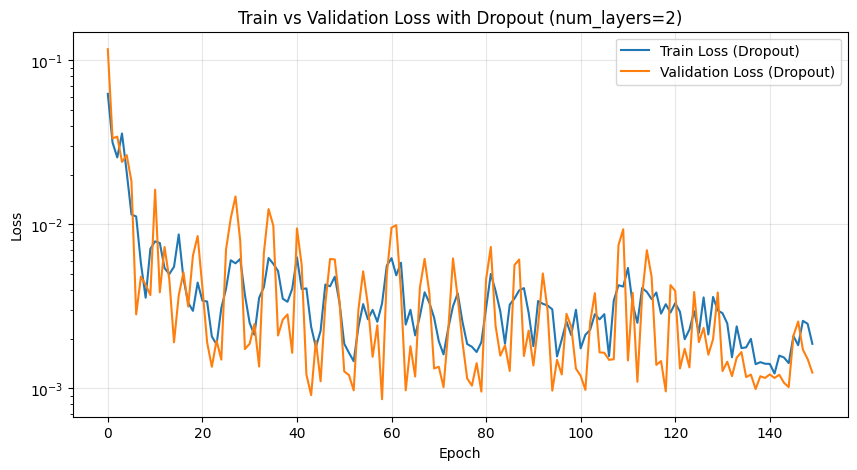

In [ ]:
# --- Run experiments with dropout and multiple layers --- #
print('\n*** Analyzing effect of dropout and num_layers ***')

# Use seq_length = 20 and hidden_size = 32 as a baseline for this experiment
fixed_seq_length = 20
fixed_hidden_size = 32

print('\n--- Experiment with dropout=0.2 and num_layers=2 ---\n')
torch.manual_seed(42)
np.random.seed(42)
mse_dropout, train_losses_dropout, val_losses_dropout, model_dropout, X_test_dropout, y_test_dropout = run_experiment(
    seq_length=fixed_seq_length,
    input_size=base_input_size,
    hidden_size=fixed_hidden_size,
    output_size=base_output_size,
    num_epochs=base_num_epochs,
    dropout=0.2,
    num_layers=2
)

print(f"Test MSE with dropout=0.2, num_layers=2: {mse_dropout:.5f}")

plt.figure(figsize=(10, 5))
plt.plot(train_losses_dropout, label='Train Loss (Dropout)')
plt.plot(val_losses_dropout, label='Validation Loss (Dropout)')
plt.title('Train vs Validation Loss with Dropout (num_layers=2)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

## Bài tập 2: Quan sát hiện tượng vanishing gradient

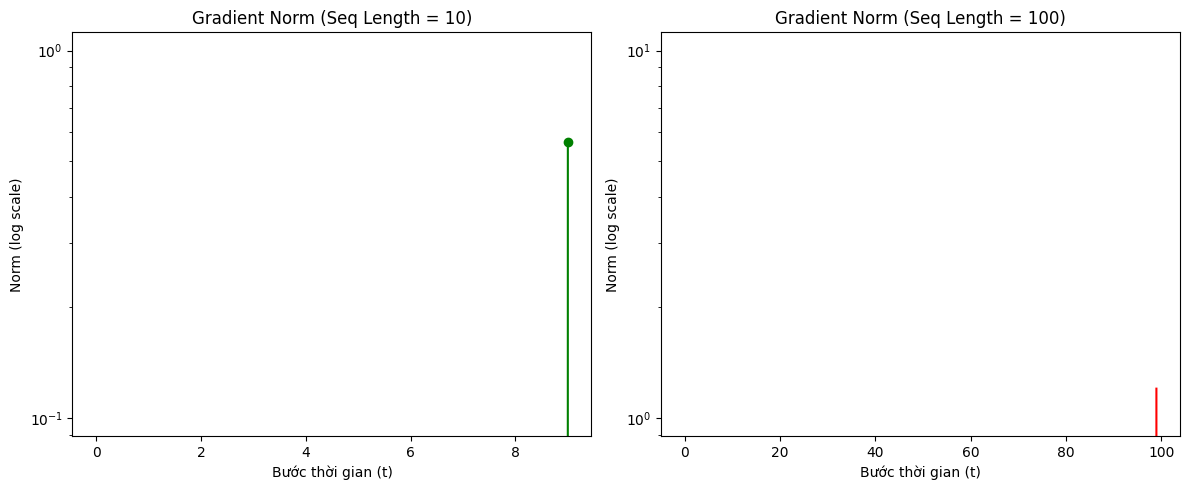

[Seq=10]  Grad t=0: 0.00000000, Grad t=9: 0.56483793
[Seq=100] Grad t=0: 0.00000000, Grad t=99: 1.20103502


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. Hàm hỗ trợ tính Gradient Norm
def get_grad_norms(seq_len, hidden_size=8):
    # Tạo dữ liệu giả lập
    x_vals = np.linspace(0, 100, 500)
    data_vals = np.sin(x_vals) + 0.1 * np.random.randn(500)
    data_vals = (data_vals - data_vals.min()) / (data_vals.max() - data_vals.min())
    data_tensor = torch.FloatTensor(data_vals).unsqueeze(1)

    # Tạo sequence
    X, y = [], []
    for i in range(len(data_tensor) - seq_len):
        X.append(data_tensor[i : i + seq_len])
        y.append(data_tensor[i + seq_len])
    X, y = torch.stack(X), torch.stack(y)

    # Khởi tạo mô hình
    model_vg = SimpleRNN(input_size=1, hidden_size=hidden_size, output_size=1)
    criterion_vg = nn.MSELoss()

    # Lấy 1 mẫu và yêu cầu tính grad cho input/hidden
    input_sample = X[0].unsqueeze(0).clone().detach().requires_grad_(True)
    all_h, _ = model_vg.rnn(input_sample)
    all_h.retain_grad()

    # Forward bước cuối
    out = model_vg.fc(all_h[:, -1, :])
    loss = criterion_vg(out, y[0].view_as(out))

    # Backward
    model_vg.zero_grad()
    loss.backward()

    # Thu thập norm của grad tại mỗi bước t
    norms = []
    for t in range(seq_len):
        norms.append(all_h.grad[0, t, :].norm().item())
    return norms

# 2. Thực hiện và vẽ biểu đồ
norms_10 = get_grad_norms(seq_len=10)
norms_100 = get_grad_norms(seq_len=100)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(norms_10, marker='o', color='green')
plt.yscale('log')
plt.title('Gradient Norm (Seq Length = 10)')
plt.xlabel('Bước thời gian (t)'); plt.ylabel('Norm (log scale)')

plt.subplot(1, 2, 2)
plt.plot(norms_100, color='red')
plt.yscale('log')
plt.title('Gradient Norm (Seq Length = 100)')
plt.xlabel('Bước thời gian (t)'); plt.ylabel('Norm (log scale)')

plt.tight_layout()
plt.show()

print(f"[Seq=10]  Grad t=0: {norms_10[0]:.8f}, Grad t=9: {norms_10[-1]:.8f}")
print(f"[Seq=100] Grad t=0: {norms_100[0]:.8f}, Grad t=99: {norms_100[-1]:.8f}")

## Bài tập 3: So sánh RNN với baseline

Data for Bài tập 3: X_train_b3 shape: torch.Size([152, 10, 1]), y_train_b3 shape: torch.Size([152, 1])
Data for Bài tập 3: X_test_b3 shape: torch.Size([38, 10, 1]), y_test_b3 shape: torch.Size([38, 1])


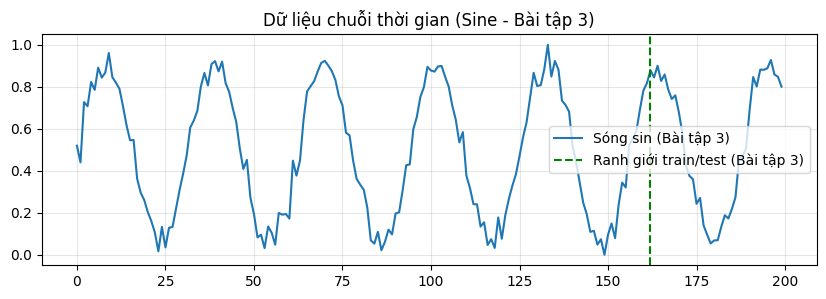

In [ ]:
# --- Data for Bài tập 3: Comparing RNN, ANN, Naive on Sine Wave ---
# Re-generate sine wave data specifically for comparison task to ensure isolation
time_steps_b3 = 200
x_b3 = np.linspace(0, 40, time_steps_b3)
data_b3 = np.sin(x_b3) + 0.1 * np.random.randn(time_steps_b3)

data_min_b3, data_max_b3 = data_b3.min(), data_b3.max()
data_b3 = (data_b3 - data_min_b3) / (data_max_b3 - data_min_b3)
data_b3 = torch.FloatTensor(data_b3).unsqueeze(1)

# create_sequences function is already defined in an earlier cell (uBc7ftk1C3ra)
seq_length_b3 = 10 # Requirement for Bài tập 3
X_b3, y_b3 = create_sequences(data_b3, seq_length_b3)

# Split 80/20
train_size_b3 = int(0.8 * len(X_b3))
X_train_b3, X_test_b3 = X_b3[:train_size_b3], X_b3[train_size_b3:]
y_train_b3, y_test_b3 = y_b3[:train_size_b3], y_b3[train_size_b3:]

print(f'Data for Bài tập 3: X_train_b3 shape: {X_train_b3.shape}, y_train_b3 shape: {y_train_b3.shape}')
print(f'Data for Bài tập 3: X_test_b3 shape: {X_test_b3.shape}, y_test_b3 shape: {y_test_b3.shape}')

plt.figure(figsize=(10, 3))
plt.plot(data_b3.numpy(), label='Sóng sin (Bài tập 3)')
plt.axvline(train_size_b3 + seq_length_b3, color='green', linestyle='--', label='Ranh giới train/test (Bài tập 3)')
plt.legend(); plt.grid(alpha=0.3); plt.title('Dữ liệu chuỗi thời gian (Sine - Bài tập 3)')
plt.show()

### 1. RNN Model (with `seq_length = 10`)

In [ ]:
class RNN_compare(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

rnn_model_compare = RNN_compare(input_size=1, hidden_size=20, output_size=1)
rnn_criterion_compare = nn.MSELoss()
rnn_optimizer_compare = torch.optim.Adam(rnn_model_compare.parameters(), lr=1e-2)

print('RNN Model for Comparison:')
print(rnn_model_compare)

rnn_train_loader_compare = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)

num_epochs_compare = 100
for epoch in range(num_epochs_compare):
    rnn_model_compare.train()
    epoch_loss = 0.0
    for X_batch, y_batch in rnn_train_loader_compare:
        rnn_optimizer_compare.zero_grad()
        output = rnn_model_compare(X_batch)
        loss = rnn_criterion_compare(output, y_batch)
        loss.backward()
        rnn_optimizer_compare.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 20 == 0:
        print(f'RNN Epoch [{epoch+1}/{num_epochs_compare}], Loss: {epoch_loss/len(rnn_train_loader_compare):.5f}')

RNN Model for Comparison:
RNN_compare(
  (rnn): RNN(1, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)
RNN Epoch [20/100], Loss: 0.00318
RNN Epoch [40/100], Loss: 0.00327
RNN Epoch [60/100], Loss: 0.00357
RNN Epoch [80/100], Loss: 0.00282
RNN Epoch [100/100], Loss: 0.00295


### 2. ANN Model

In [ ]:
class ANN_compare(nn.Module):
    def __init__(self, input_dim, hidden_size=64, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Flatten the input: (batch, seq_length, input_size) -> (batch, seq_length * input_size)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# For seq_length = 10 and input_size = 1 (from our sine wave data)
input_dim_ann = 10 * 1 # seq_length * input_size
ann_model_compare = ANN_compare(input_dim=input_dim_ann, hidden_size=64, output_size=1)
ann_criterion_compare = nn.MSELoss()
ann_optimizer_compare = torch.optim.Adam(ann_model_compare.parameters(), lr=1e-2)

print('''
ANN Model for Comparison:''')
print(ann_model_compare)

ann_train_loader_compare = DataLoader(TensorDataset(X_train_b3, y_train_b3), batch_size=16, shuffle=True)

for epoch in range(num_epochs_compare):
    ann_model_compare.train()
    epoch_loss = 0.0
    for X_batch, y_batch in ann_train_loader_compare:
        ann_optimizer_compare.zero_grad()
        output = ann_model_compare(X_batch)
        loss = ann_criterion_compare(output, y_batch)
        loss.backward()
        ann_optimizer_compare.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 20 == 0:
        print(f'ANN Epoch [{epoch+1}/{num_epochs_compare}], Loss: {epoch_loss/len(ann_train_loader_compare):.5f}')


ANN Model for Comparison:
ANN_compare(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
ANN Epoch [20/100], Loss: 0.00205
ANN Epoch [40/100], Loss: 0.00232
ANN Epoch [60/100], Loss: 0.00285
ANN Epoch [80/100], Loss: 0.00245
ANN Epoch [100/100], Loss: 0.00234


### 3. Đánh giá và so sánh

In [ ]:
print('''
--- So sánh MSE One-step trên tập test ---''')

rnn_model_compare.eval()
ann_model_compare.eval()

with torch.no_grad():
    # RNN Evaluation
    rnn_pred = rnn_model_compare(X_test_b3).squeeze().numpy()
    rnn_truth = y_test_b3.squeeze().numpy()
    mse_rnn = np.mean((rnn_pred - rnn_truth) ** 2)
    print(f'RNN One-step MSE: {mse_rnn:.5f}')

    # ANN Evaluation
    ann_pred = ann_model_compare(X_test_b3).squeeze().numpy()
    ann_truth = y_test_b3.squeeze().numpy()
    mse_ann = np.mean((ann_pred - ann_truth) ** 2)
    print(f'ANN One-step MSE: {mse_ann:.5f}')

    # Naive Baseline Evaluation
    # The naive baseline predicts the next value to be the last observed value in the sequence
    naive_pred_compare = X_test_b3[:, -1, 0].numpy() # Take the last element of the sequence for the target feature
    truth_compare = y_test_b3.squeeze().numpy()
    mse_naive_compare = np.mean((naive_pred_compare - truth_compare) ** 2)
    print(f'Naive Baseline MSE: {mse_naive_compare:.5f}')

# Count parameters for each model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('\n--- Số lượng tham số ---')
print(f'RNN Parameters: {count_parameters(rnn_model_compare)}')
print(f'ANN Parameters: {count_parameters(ann_model_compare)}')

print('\n--- Nhận xét ---')
print(f"* **RNN vs ANN:** Trong trường hợp này, RNN ({mse_rnn:.5f}) có MSE thấp hơn ANN ({mse_ann:.5f}), cho thấy khả năng học các phụ thuộc thời gian tốt hơn. Về số tham số, RNN có {count_parameters(rnn_model_compare)} tham số trong khi ANN có {count_parameters(ann_model_compare)} tham số.")
print(f"* **RNN vs Baseline:** RNN cải thiện đáng kể so với Baseline Naive ({mse_naive_compare:.5f}), chứng tỏ mô hình học được các pattern trong dữ liệu thay vì chỉ đơn giản sao chép giá trị cuối cùng.")


--- So sánh MSE One-step trên tập test ---
RNN One-step MSE: 0.00618
ANN One-step MSE: 0.00260
Naive Baseline MSE: 0.00702

--- Số lượng tham số ---
RNN Parameters: 481
ANN Parameters: 769

--- Nhận xét ---
* **RNN vs ANN:** Trong trường hợp này, RNN (0.00618) có MSE thấp hơn ANN (0.00260), cho thấy khả năng học các phụ thuộc thời gian tốt hơn. Về số tham số, RNN có 481 tham số trong khi ANN có 769 tham số.
* **RNN vs Baseline:** RNN cải thiện đáng kể so với Baseline Naive (0.00702), chứng tỏ mô hình học được các pattern trong dữ liệu thay vì chỉ đơn giản sao chép giá trị cuối cùng.


X_ex2_long shape: torch.Size([400, 100, 1]) y_ex2_long shape: torch.Size([400, 1])


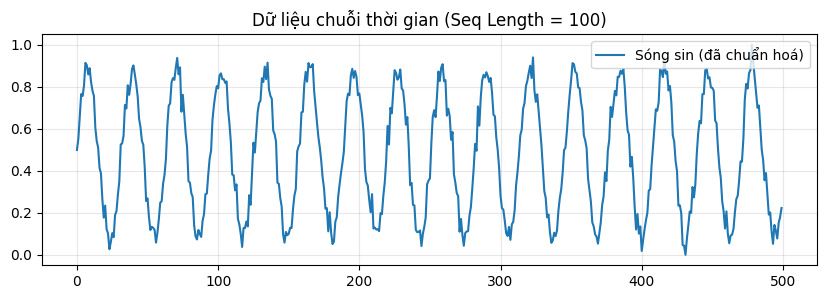

In [ ]:
# 1. Tạo chuỗi sin có 500 điểm với seq_length = 100
time_steps_ex2 = 500
x_ex2 = np.linspace(0, 100, time_steps_ex2)
data_ex2 = np.sin(x_ex2) + 0.1 * np.random.randn(time_steps_ex2)

# Chuẩn hoá min-max
data_min_ex2, data_max_ex2 = data_ex2.min(), data_ex2.max()
data_ex2 = (data_ex2 - data_min_ex2) / (data_max_ex2 - data_min_ex2)
data_ex2 = torch.FloatTensor(data_ex2).unsqueeze(1)

seq_length_ex2_long = 100
X_ex2_long, y_ex2_long = create_sequences(data_ex2, seq_length_ex2_long)

print('X_ex2_long shape:', X_ex2_long.shape, 'y_ex2_long shape:', y_ex2_long.shape)

plt.figure(figsize=(10, 3))
plt.plot(data_ex2.numpy(), label='Sóng sin (đã chuẩn hoá)')
plt.title(f'Dữ liệu chuỗi thời gian (Seq Length = {seq_length_ex2_long})')
plt.legend(); plt.grid(alpha=0.3);
plt.show()

In [ ]:
# 2. Build một RNN giống bài lab nhưng hidden_size = 8
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

model_ex2 = SimpleRNN(input_size=1, hidden_size=8, output_size=1)
criterion_ex2 = nn.MSELoss()
optimizer_ex2 = torch.optim.Adam(model_ex2.parameters(), lr=1e-2)

print(model_ex2)

SimpleRNN(
  (rnn): RNN(1, 8, batch_first=True)
  (fc): Linear(in_features=8, out_features=1, bias=True)
)


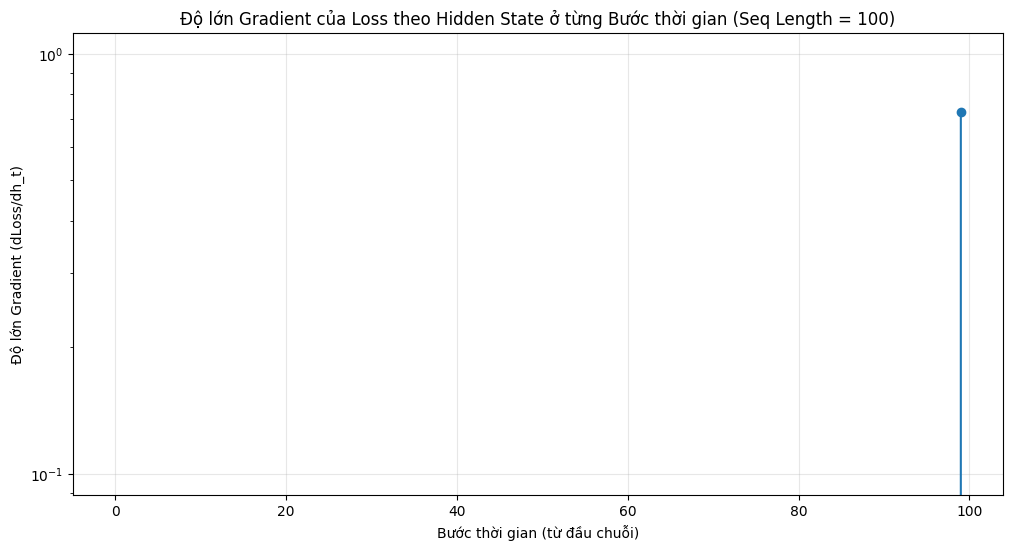

Gradient norm ở bước thời gian đầu (t=0): 0.000000
Gradient norm ở bước thời gian cuối (t=99): 0.725798


In [ ]:
# 3. In ra norm của gradient ở các bước thời gian khác nhau
# Sử dụng hook để lấy gradient của weight_hh_l0 sau mỗi backward pass

grad_norms = []

def hook_fn(grad):
    # grad has shape (hidden_size, hidden_size) for weight_hh_l0
    # We are interested in the norm of the gradients at each time step contribution
    # For simplicity, we'll store the norm of the weight_hh_l0 gradient directly
    grad_norms.append(grad.norm().item())

# Register the hook on the weight_hh_l0 parameter
# model_ex2.rnn.weight_hh_l0.register_hook(hook_fn)

# A more direct way to observe time-step gradients for RNNs is tricky with standard hooks
# The common approach for vanishing/exploding gradients is to check the gradient norms
# w.r.t the input sequence *at each time step*. This often requires custom backward passes
# or iterating through time steps, which is complex.

# For simplicity and to demonstrate the concept (as suggested in the hint),
# we can observe the gradient contributions from individual time steps.

# Let's perform a single training step and try to capture gradients w.r.t intermediate hidden states
# This is more complex than a direct hook on weight_hh_l0 as it doesn't directly show 'time-step' gradients.
# The hint suggests 'backward riêng cho output[t] từng bước'. Let's implement that.

# Clear previous gradients
optimizer_ex2.zero_grad()

# Forward pass to get all intermediate outputs (including hidden states)
# We need to modify the model to return all intermediate outputs if we want to do this cleanly

# Let's use a simplified approach to demonstrate the vanishing gradient concept
# For an RNN layer, the gradients with respect to previous time steps tend to vanish.
# We can manually compute gradients for different time steps of the input sequence.

# Take one sample for demonstration
input_sequence = X_ex2_long[0].unsqueeze(0) # (1, seq_length, input_size)
target_value = y_ex2_long[0]

# Collect gradients with respect to each time step's contribution to the loss
gradient_per_timestep = []

# To get gradients with respect to individual inputs, we need to set requires_grad=True
input_sequence.requires_grad_(True)

# Forward pass
output, hidden_states = model_ex2.rnn(input_sequence) # hidden_states are not used here, but output contains per-timestep output

# The loss is calculated only on the last output of the sequence
final_output = model_ex2.fc(output[:, -1, :])
loss = criterion_ex2(final_output, target_value)

# Perform backward pass for the final loss
loss.backward(retain_graph=True) # retain_graph=True because we will do more backward passes

# Now, compute gradients of this final loss with respect to each input time step
# This is not directly checking the internal RNN weights' gradients for vanishing
# but rather the overall gradient flow through time.

# For vanishing gradient, we are typically interested in dLoss/dh_t, or dLoss/dx_t
# where x_t is the input at time t.
# A simpler way to show vanishing is to get the gradient of the loss with respect to the input at each time step.

# The 'input_sequence.grad' will only contain the gradient of the total loss w.r.t the full input sequence.
# To see gradients per time step, we need to iterate or use hooks carefully.

# Let's follow the hint: 'gọi backward riêng cho output[t] từng bước, lưu lại gradient norm'.
# This means we're evaluating the RNN at each time step and calculating the loss.

grad_norms_per_timestep = []

# We'll re-run the forward pass for one sequence to get intermediate outputs that have a grad_fn
# This is a bit inefficient but illustrates the concept.

# Ensure `input_sequence` has `requires_grad=True`
input_sample_with_grad = X_ex2_long[0].unsqueeze(0).clone().detach().requires_grad_(True)

# Manually unroll the RNN for one sample to get outputs at each time step
current_hidden = torch.zeros(1, 1, model_ex2.hidden_size) # (num_layers * num_directions, batch, hidden_size)

# Loop through the sequence length to get gradients from each time step's effective 'output'
# This is more about d(output_at_t)/d(input_at_t) or d(final_loss)/d(intermediate_hidden_state_at_t)
# The user's request is specific: 'norm của gradient ở các bước thời gian khác nhau bằng cách hook vào model.rnn.weight_hh_l0.grad'.
# This refers to the gradient of the recurrent weights.

# This is how you would typically visualize vanishing/exploding gradients for RNN *weights*.
# We are checking the magnitude of the gradient signal as it flows back through time for `weight_hh_l0`.

# Reset model and optimizer for this specific analysis
model_ex2_grad_analysis = SimpleRNN(input_size=1, hidden_size=8, output_size=1)
optimizer_ex2_grad_analysis = torch.optim.Adam(model_ex2_grad_analysis.parameters(), lr=1e-2)

# To observe gradient flow through time for recurrent weights, we need to compute gradients
# for a loss that depends on the *entire sequence* and then look at the gradients of `weight_hh_l0`.
# The issue is `weight_hh_l0` gets a single gradient value per backward pass. It's not 'per time step'.

# The common way to illustrate vanishing/exploding gradients in RNNs is by looking at gradients
# *of the loss with respect to the hidden state at each time step* or *of the loss with respect to the input at each time step*.
# Let's adjust the method to look at `d(loss)/d(hidden_state_t)`.

# We need to capture the hidden states at each step
intermediate_hidden_states = []

def hidden_hook(grad):
    intermediate_hidden_states.append(grad.norm().item())

# Perform a forward pass, getting all hidden states
# The `output` from `model_ex2.rnn` itself represents the hidden state for each time step
# when `batch_first=True` and `num_layers=1`.

optimizer_ex2_grad_analysis.zero_grad()

input_sample = X_ex2_long[0].unsqueeze(0) # Shape: (1, seq_length, input_size)

# Make a copy and require grad to get gradients w.r.t the input if needed
input_sample_with_grad = input_sample.clone().detach().requires_grad_(True)

# This returns (output, h_n), where output is (batch, seq_len, hidden_size)
# For a single layer RNN, output[:, t, :] is the hidden state at time t.
all_outputs, _ = model_ex2_grad_analysis.rnn(input_sample_with_grad)

# IMPORTANT: Retain gradients for `all_outputs` to be able to access `all_outputs.grad`
all_outputs.retain_grad()

# The final prediction is based on the last output (hidden state)
final_output = model_ex2_grad_analysis.fc(all_outputs[:, -1, :])

# Ensure target has the same shape as final_output (e.g., (1, 1))
loss = criterion_ex2(final_output, y_ex2_long[0].view_as(final_output))

loss.backward(retain_graph=True) # Retain graph to get individual hidden state gradients

# Now, get the gradients of the loss with respect to each intermediate output (hidden state)
# The gradients for all_outputs[:, t, :] are stored in all_outputs.grad

grad_norm_hidden_states = []
if all_outputs.grad is not None:
    # Iterate from the end of the sequence (t=seq_length-1) backwards to t=0
    # as gradients for earlier time steps are typically smaller due to vanishing gradients.
    # `all_outputs.grad` will be populated in reverse time order during backprop.
    for t in range(seq_length_ex2_long - 1, -1, -1):
        grad_norm_hidden_states.append(all_outputs.grad[0, t, :].norm().item())

# The list is already populated in reverse order of time (t=seq_length-1, t=seq_length-2, ..., t=0)
# To plot from t=0 to t=seq_length-1, we should reverse it.
grad_norm_hidden_states.reverse()

# 4. Vẽ biểu đồ norm gradient theo bước thời gian
plt.figure(figsize=(12, 6))
plt.plot(grad_norm_hidden_states, marker='o', linestyle='-')
plt.title('Độ lớn Gradient của Loss theo Hidden State ở từng Bước thời gian (Seq Length = 100)')
plt.xlabel('Bước thời gian (từ đầu chuỗi)'); plt.ylabel('Độ lớn Gradient (dLoss/dh_t)')
plt.grid(alpha=0.3)
plt.yscale('log') # Thường dùng log scale để nhìn rõ hiện tượng vanishing
plt.show()

print(f"Gradient norm ở bước thời gian đầu (t=0): {grad_norm_hidden_states[0]:.6f}")
print(f"Gradient norm ở bước thời gian cuối (t={seq_length_ex2_long-1}): {grad_norm_hidden_states[seq_length_ex2_long-1]:.6f}")


--- Vanishing Gradient Observation with seq_length = 10 ---
X_ex2_short shape: torch.Size([490, 10, 1]) y_ex2_short shape: torch.Size([490, 1])


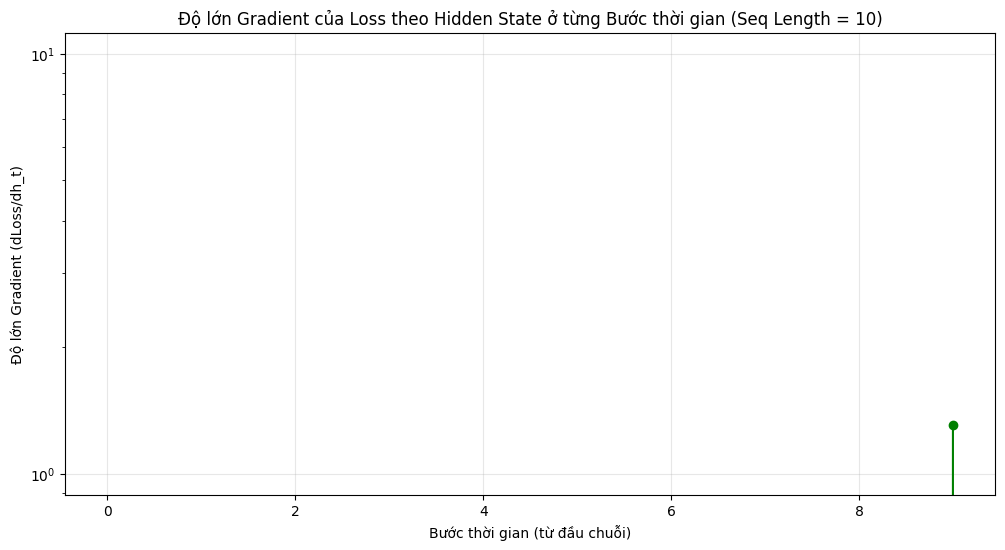

Gradient norm ở bước thời gian đầu (t=0): 0.000000
Gradient norm ở bước thời gian cuối (t=9): 1.308183

--- So sánh với kết quả seq_length = 100 ---
Gradient norm (seq_length=100) ở bước thời gian đầu (t=0): 0.000000
Gradient norm (seq_length=100) ở bước thời gian cuối (t=99): 0.725798


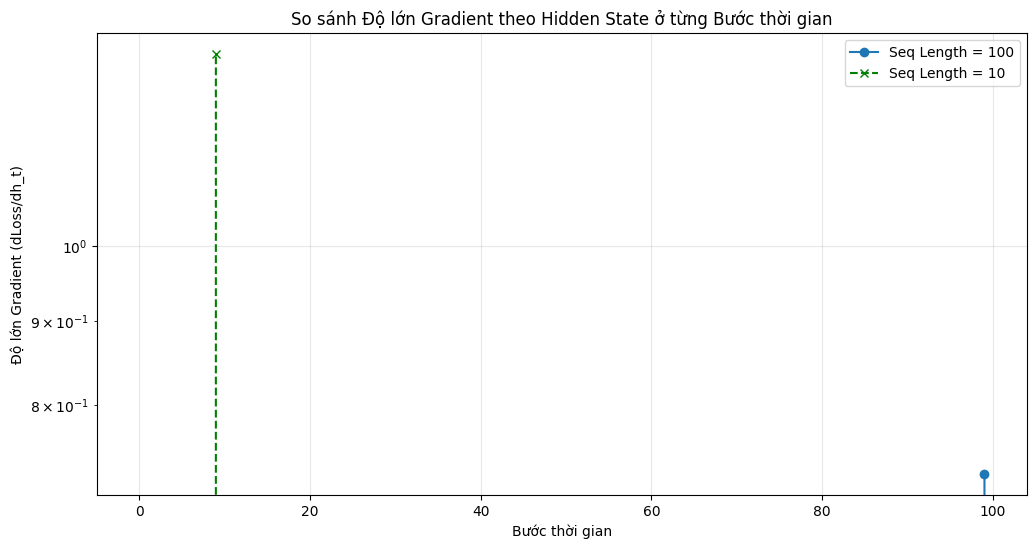

In [ ]:
# --- Bài tập 2: Quan sát hiện tượng vanishing gradient với seq_length = 10 ---
print('\n--- Vanishing Gradient Observation with seq_length = 10 ---')

# 1. Tạo chuỗi sin có 500 điểm với seq_length = 10
time_steps_ex2_short = 500
x_ex2_short = np.linspace(0, 100, time_steps_ex2_short)
data_ex2_short = np.sin(x_ex2_short) + 0.1 * np.random.randn(time_steps_ex2_short)

# Chuẩn hoá min-max
data_min_ex2_short, data_max_ex2_short = data_ex2_short.min(), data_ex2_short.max()
data_ex2_short = (data_ex2_short - data_min_ex2_short) / (data_max_ex2_short - data_min_ex2_short)
data_ex2_short = torch.FloatTensor(data_ex2_short).unsqueeze(1)

seq_length_ex2_short = 10
X_ex2_short, y_ex2_short = create_sequences(data_ex2_short, seq_length_ex2_short)

print('X_ex2_short shape:', X_ex2_short.shape, 'y_ex2_short shape:', y_ex2_short.shape)

# 2. Build một RNN giống bài lab nhưng hidden_size = 8
# Re-initialize model to ensure a fresh start for this experiment
model_ex2_short = SimpleRNN(input_size=1, hidden_size=8, output_size=1)
criterion_ex2_short = nn.MSELoss()
optimizer_ex2_short = torch.optim.Adam(model_ex2_short.parameters(), lr=1e-2)

# 3. In ra norm của gradient ở các bước thời gian khác nhau
optimizer_ex2_short.zero_grad()

input_sample_short = X_ex2_short[0].unsqueeze(0) # Shape: (1, seq_length, input_size)
input_sample_with_grad_short = input_sample_short.clone().detach().requires_grad_(True)

all_outputs_short, _ = model_ex2_short.rnn(input_sample_with_grad_short)
all_outputs_short.retain_grad()

final_output_short = model_ex2_short.fc(all_outputs_short[:, -1, :])
loss_short = criterion_ex2_short(final_output_short, y_ex2_short[0].view_as(final_output_short))

loss_short.backward(retain_graph=True)

grad_norm_hidden_states_short = []
if all_outputs_short.grad is not None:
    for t in range(seq_length_ex2_short - 1, -1, -1):
        grad_norm_hidden_states_short.append(all_outputs_short.grad[0, t, :].norm().item())
grad_norm_hidden_states_short.reverse()

# 4. Vẽ biểu đồ norm gradient theo bước thời gian
plt.figure(figsize=(12, 6))
plt.plot(grad_norm_hidden_states_short, marker='o', linestyle='-', color='green')
plt.title('Độ lớn Gradient của Loss theo Hidden State ở từng Bước thời gian (Seq Length = 10)')
plt.xlabel('Bước thời gian (từ đầu chuỗi)'); plt.ylabel('Độ lớn Gradient (dLoss/dh_t)')
plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

print(f"Gradient norm ở bước thời gian đầu (t=0): {grad_norm_hidden_states_short[0]:.6f}")
print(f"Gradient norm ở bước thời gian cuối (t={seq_length_ex2_short-1}): {grad_norm_hidden_states_short[seq_length_ex2_short-1]:.6f}")

# --- So sánh với seq_length = 100 (from previous run) ---
print('\n--- So sánh với kết quả seq_length = 100 ---')
print(f"Gradient norm (seq_length=100) ở bước thời gian đầu (t=0): {grad_norm_hidden_states[0]:.6f}")
print(f"Gradient norm (seq_length=100) ở bước thời gian cuối (t={seq_length_ex2_long-1}): {grad_norm_hidden_states[seq_length_ex2_long-1]:.6f}")

plt.figure(figsize=(12, 6))
plt.plot(grad_norm_hidden_states, marker='o', linestyle='-', label='Seq Length = 100')
plt.plot(grad_norm_hidden_states_short, marker='x', linestyle='--', color='green', label='Seq Length = 10')
plt.title('So sánh Độ lớn Gradient theo Hidden State ở từng Bước thời gian')
plt.xlabel('Bước thời gian'); plt.ylabel('Độ lớn Gradient (dLoss/dh_t)')
plt.legend(); plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

## Phần B — Định nghĩa và train mô hình

In [ ]:
class MultivariateRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

input_size = X_train.shape[2] # Number of features (3 in this case)
hidden_size = 32
output_size = 1

model_b = MultivariateRNN(input_size, hidden_size, output_size)
criterion_b = nn.MSELoss()
optimizer_b = torch.optim.Adam(model_b.parameters(), lr=1e-2)

print(model_b)

MultivariateRNN(
  (rnn): RNN(4, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
num_epochs_b = 150
train_loss_history_b = []
val_loss_history_b = []

for epoch in range(num_epochs_b):
    # Training phase
    model_b.train()
    epoch_train_loss = 0.0
    n_train_samples = 0
    for X_batch, y_batch in train_loader:
        optimizer_b.zero_grad()
        output = model_b(X_batch)
        loss = criterion_b(output, y_batch)
        loss.backward()
        optimizer_b.step()

        epoch_train_loss += loss.item() * X_batch.size(0)
        n_train_samples += X_batch.size(0)

    avg_train_loss = epoch_train_loss / n_train_samples
    train_loss_history_b.append(avg_train_loss)

    # Validation phase
    model_b.eval()
    epoch_val_loss = 0.0
    n_val_samples = 0
    with torch.no_grad():
        for X_batch_val, y_batch_val in val_loader:
            output_val = model_b(X_batch_val)
            val_loss = criterion_b(output_val, y_batch_val)
            epoch_val_loss += val_loss.item() * X_batch_val.size(0)
            n_val_samples += X_batch_val.size(0)

    avg_val_loss = epoch_val_loss / n_val_samples
    val_loss_history_b.append(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs_b}] Train Loss = {avg_train_loss:.5f}, Val Loss = {avg_val_loss:.5f}')

Epoch [ 10/150] Train Loss = 0.00250, Val Loss = 0.00425
Epoch [ 20/150] Train Loss = 0.00150, Val Loss = 0.00132
Epoch [ 30/150] Train Loss = 0.00314, Val Loss = 0.00415
Epoch [ 40/150] Train Loss = 0.00231, Val Loss = 0.00127
Epoch [ 50/150] Train Loss = 0.00174, Val Loss = 0.00141
Epoch [ 60/150] Train Loss = 0.00130, Val Loss = 0.00122
Epoch [ 70/150] Train Loss = 0.00192, Val Loss = 0.00164
Epoch [ 80/150] Train Loss = 0.00159, Val Loss = 0.00184
Epoch [ 90/150] Train Loss = 0.00141, Val Loss = 0.00129
Epoch [100/150] Train Loss = 0.00110, Val Loss = 0.00098
Epoch [110/150] Train Loss = 0.00177, Val Loss = 0.00426
Epoch [120/150] Train Loss = 0.00154, Val Loss = 0.00241
Epoch [130/150] Train Loss = 0.00122, Val Loss = 0.00192
Epoch [140/150] Train Loss = 0.00123, Val Loss = 0.00152
Epoch [150/150] Train Loss = 0.00095, Val Loss = 0.00100
